# Análise Exploratória e Limpeza de Dados de Vendas com Pandas 🛒

## 1. O Problema de Negócio

**Contexto:** Muitas empresas de e-commerce em fase de expansão sofrem com um problema crônico: possuem um grande volume de dados transacionais, mas não conseguem extrair inteligência deles devido à baixa qualidade do armazenamento bruto. 

**O Desafio:** Atuar em um cenário onde a gestão enfrenta dificuldades para tomar decisões estratégicas devido a problemas estruturais nos dados, tais como:
* **Valores Ausentes:** Pedidos sem registro de quantidade ou status logístico;
* **Inconsistências:** Formatação incorreta (ex: preços cadastrados como texto);
* **Duplicidade:** Registros repetidos que inflavam artificialmente a receita;
* **Outliers:** Dados anômalos que distorciam as médias de vendas.

**Meu Objetivo:** Atuar na engenharia de atributos e limpeza profunda deste banco de dados utilizando `Pandas`. Minha meta final é transformar esse ambiente caótico em um *dataset* confiável, capaz de responder com precisão matemática a três perguntas cruciais:
1. Quais são os produtos e categorias mais lucrativos?
2. Qual é a tendência de vendas ao longo do tempo?
3. Como está a eficiência da operação logística?

## 2. Importação das Bibliotecas

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configura o estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Passo 1 - Geração de Dados Sintéticos com Pandas e NumPy
Criei um DataFrame com dados fictícios que simulam problemas comuns: valores ausentes, tipos de dados incorretos, duplicatas e outliers.

In [3]:
print("\nGerando conjunto de dados fictícios...")

# Define a semente para garantir reprodutividade
np.random.seed(42)

catalogo_produtos = {
    'Smartphone': {'categoria': 'Eletrônicos', 'preco': 5999.90},
    'Notebook': {'categoria': 'Eletrônicos', 'preco': 8500.00},
    'Fone de Ouvido': {'categoria': 'Acessórios', 'preco': 799.50},
    'Smartwatch': {'categoria': 'Acessórios', 'preco': 2100.00},
    'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 850.00},
}

produto_escolhido = np.random.choice(list(catalogo_produtos.keys()), size=100)

data = {
    'ID_Pedido': range(1001, 1101),
    'Data_Compra': pd.to_datetime(pd.date_range(start='2026-07-01', periods=100, freq='D')) - pd.to_timedelta(np.random.randint(0, 30, size=100), unit='D'),
    'Cliente_ID': np.random.randint(100, 150, size=100),
    'Produto': produto_escolhido,
    'Categoria': [catalogo_produtos[p]['categoria'] for p in produto_escolhido],
    'Quantidade': np.random.randint(1, 5, size=100),
    'Preco_Unitario': [catalogo_produtos[p]['preco'] for p in produto_escolhido],
    'Status_Entrega': np.random.choice(['Entregue', 'Pendente', 'Cancelado'], size=100, p=[0.8, 0.15, 0.05])
}

# Cria o dataframe a partir do dicionário acima
df_vendas = pd.DataFrame(data)

# Introduz Problemas nos Dados de Forma Sintética
print("\nIntroduzindo problemas nos dados para a limpeza...\n")

# 1. Valores Ausentes (NaN)
df_vendas.loc[5:10, 'Quantidade'] = np.nan
df_vendas.loc[20:22, 'Status_Entrega'] = np.nan
df_vendas.loc[30, 'Cliente_ID'] = np.nan

# 2. Dados Duplicados
df_vendas = pd.concat([df_vendas, df_vendas.head(3)], ignore_index = True)

# 3. Tipos de Dados Incorretos
df_vendas['Preco_Unitario'] = df_vendas['Preco_Unitario'].astype(str)
df_vendas.loc[15, 'Preco_Unitario'] = 'valor_invalido'              # Simulando um erro de digitação
df_vendas['Cliente_ID'] = df_vendas['Cliente_ID'].astype(str)

# 4. Outliers
df_vendas.loc[50, 'Quantidade'] = 50 # Um valor claramente fora do padrão

print("Dados gerados com sucesso!\n")


Gerando conjunto de dados fictícios...

Introduzindo problemas nos dados para a limpeza...

Dados gerados com sucesso!



In [4]:
df_vendas.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-04,141.0,Smartwatch,Acessórios,4.0,2100.0,Entregue
1,1002,2026-06-26,143.0,Teclado Mecânico,Acessórios,3.0,850.0,Entregue
2,1003,2026-06-25,123.0,Fone de Ouvido,Acessórios,1.0,799.5,Entregue
3,1004,2026-06-27,114.0,Teclado Mecânico,Acessórios,4.0,850.0,Entregue
4,1005,2026-06-24,131.0,Teclado Mecânico,Acessórios,4.0,850.0,Entregue


In [5]:
df_vendas.tail()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
98,1099,2026-10-07,132.0,Notebook,Eletrônicos,4.0,8500.0,Entregue
99,1100,2026-09-20,123.0,Smartphone,Eletrônicos,3.0,5999.9,Pendente
100,1001,2026-06-04,141.0,Smartwatch,Acessórios,4.0,2100.0,Entregue
101,1002,2026-06-26,143.0,Teclado Mecânico,Acessórios,3.0,850.0,Entregue
102,1003,2026-06-25,123.0,Fone de Ouvido,Acessórios,1.0,799.5,Entregue


## Passo 2 - Análise Exploratória de Dados (EDA)
Antes de qualquer modificação, primeiro inspeciono o DataFrame para entender sua estrutura e identificar os problemas.

In [6]:
print("\n--- Informações Gerais do DataFrame (df_vendas.info()) ---\n")
df_vendas.info()


--- Informações Gerais do DataFrame (df_vendas.info()) ---

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       103 non-null    int64         
 1   Data_Compra     103 non-null    datetime64[us]
 2   Cliente_ID      102 non-null    str           
 3   Produto         103 non-null    str           
 4   Categoria       103 non-null    str           
 5   Quantidade      97 non-null     float64       
 6   Preco_Unitario  103 non-null    str           
 7   Status_Entrega  100 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 6.6 KB


In [7]:
print("\n--- Verificando valores ausentes ---\n")
print(df_vendas.isna().sum())


--- Verificando valores ausentes ---

ID_Pedido         0
Data_Compra       0
Cliente_ID        1
Produto           0
Categoria         0
Quantidade        6
Preco_Unitario    0
Status_Entrega    3
dtype: int64


In [8]:
print("\n--- Verificando a presença de registros duplicados ---\n")
print(f"Número de linhas duplicadas: {df_vendas.duplicated().sum()}")


--- Verificando a presença de registros duplicados ---

Número de linhas duplicadas: 3


In [9]:
print("\n--- Estatísticas descritivas para colunas numéricas ---\n")
# Usei o describe() para ter uma noção inicial. Note que Preco_Unitario não aparecerá por ser 'object'.
print(df_vendas.describe())


--- Estatísticas descritivas para colunas numéricas ---

         ID_Pedido                 Data_Compra  Quantidade
count   103.000000                         103   97.000000
mean   1049.087379  2026-08-03 13:30:52.427184    3.020619
min    1001.000000         2026-06-04 00:00:00    1.000000
25%    1023.500000         2026-07-11 00:00:00    1.000000
50%    1049.000000         2026-08-04 00:00:00    3.000000
75%    1074.500000         2026-08-24 00:00:00    4.000000
max    1100.000000         2026-10-07 00:00:00   50.000000
std      29.733821                         NaN    4.968609


In [10]:
print("\n--- Estatísticas descritivas para colunas categóricas ---\n")
print(df_vendas.describe(include = ['O']))


--- Estatísticas descritivas para colunas categóricas ---

       Cliente_ID     Produto   Categoria Preco_Unitario Status_Entrega
count         102         103         103            103            100
unique         40           5           2              6              3
top         131.0  Smartwatch  Acessórios         2100.0       Entregue
freq            7          27          64             27             82


In [11]:
print("\n--- Tipos de dados ---\n")
df_vendas.dtypes


--- Tipos de dados ---



ID_Pedido                  int64
Data_Compra       datetime64[us]
Cliente_ID                   str
Produto                      str
Categoria                    str
Quantidade               float64
Preco_Unitario               str
Status_Entrega               str
dtype: object

## Passo 3 - Limpeza e Pré-Processamento dos Dados
Resolvendo sistematicamente os problemas identificados na etapa de inspeção.

In [12]:
# Copiando o DataFrame para manter o original intacto
df_limpo = df_vendas.copy()

In [13]:
# --- 1. Corrigindo Tipos de Dados ---
print("Corrigindo tipos de dados...")
# Converte 'Preco_Unitario' para numérico, tratando erros
# errors='coerce' transformará valores inválidos (como 'valor_invalido') em NaN
df_limpo['Preco_Unitario'] = pd.to_numeric(df_limpo['Preco_Unitario'], errors = 'coerce')

Corrigindo tipos de dados...


In [14]:
# Converte 'Cliente_ID' para numérico, tratando erros
df_limpo['Cliente_ID'] = pd.to_numeric(df_limpo['Cliente_ID'], errors = 'coerce').astype('Int64') # Usa-se Int64 para permitir NaN

In [15]:
# Visualização das modificações
df_limpo.dtypes

ID_Pedido                  int64
Data_Compra       datetime64[us]
Cliente_ID                 Int64
Produto                      str
Categoria                    str
Quantidade               float64
Preco_Unitario           float64
Status_Entrega               str
dtype: object

In [16]:
# --- 2. Tratando Valores Ausentes (NaN) ---
print("Tratando valores ausentes...")
# Para 'Quantidade', preencho com a mediana, que é mais robusta a outliers
mediana_qtd = df_limpo['Quantidade'].median()
df_limpo.fillna({'Quantidade': mediana_qtd}, inplace = True)

Tratando valores ausentes...


,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-04,141,Smartwatch,Acessórios,4.0,2100.0,Entregue
1,1002,2026-06-26,143,Teclado Mecânico,Acessórios,3.0,850.0,Entregue
2,1003,2026-06-25,123,Fone de Ouvido,Acessórios,1.0,799.5,Entregue
3,1004,2026-06-27,114,Teclado Mecânico,Acessórios,4.0,850.0,Entregue
4,1005,2026-06-24,131,Teclado Mecânico,Acessórios,4.0,850.0,Entregue
...,...,...,...,...,...,...,...,...
98,1099,2026-10-07,132,Notebook,Eletrônicos,4.0,8500.0,Entregue
99,1100,2026-09-20,123,Smartphone,Eletrônicos,3.0,5999.9,Pendente
100,1001,2026-06-04,141,Smartwatch,Acessórios,4.0,2100.0,Entregue
101,1002,2026-06-26,143,Teclado Mecânico,Acessórios,3.0,850.0,Entregue


In [17]:
# Para 'Status_Entrega', pode-se preencher com o valor mais frequente (moda)
moda_status = df_limpo['Status_Entrega'].mode()[0]
df_limpo['Status_Entrega'] = df_limpo['Status_Entrega'].fillna(moda_status)

In [18]:
# Para 'Preco_Unitario' e 'Cliente_ID', onde o NaN foi gerado por erro ou falta de informação,
# a melhor abordagem é remover as linhas, pois não se pode inferir esses dados.
df_limpo.dropna(subset = ['Preco_Unitario', 'Cliente_ID'], inplace = True)

In [19]:
# --- 3. Removendo Duplicatas ---
print("Removendo registros duplicados...")
df_limpo.drop_duplicates(inplace = True)

Removendo registros duplicados...


Tratando outliers...


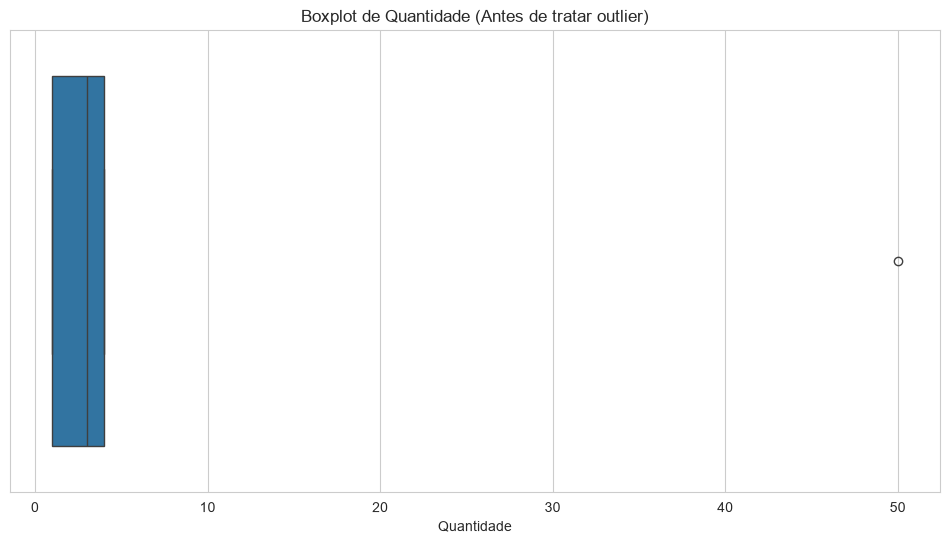

In [20]:
# --- 4. Tratando Outliers ---
# Primeiro, preciso visualizar o outlier na coluna 'Quantidade'
print("Tratando outliers...")
sns.boxplot(x = df_limpo['Quantidade'])
plt.title('Boxplot de Quantidade (Antes de tratar outlier)')
plt.show()

In [21]:
# Remove valores de 'Quantidade' que estão muito distantes da média,
# uma abordagem comum é remover valores que estão além de 3 desvios padrão da média.
limite_superior = df_limpo['Quantidade'].mean() + 3 * df_limpo['Quantidade'].std()
df_limpo = df_limpo[df_limpo['Quantidade'] < limite_superior]

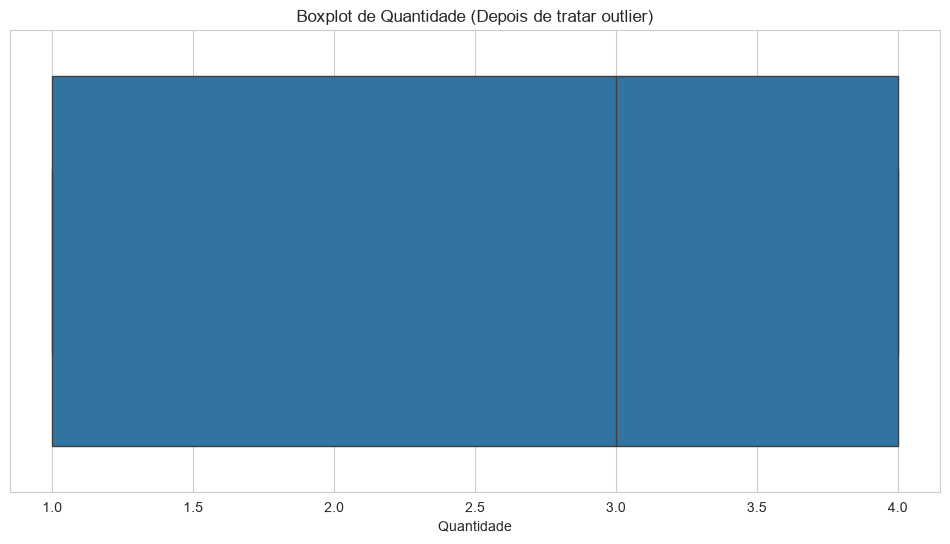

In [22]:
# Verificando o resultado
sns.boxplot(x = df_limpo['Quantidade'])
plt.title('Boxplot de Quantidade (Depois de tratar outlier)')
plt.show()

In [23]:
# --- Verificação Final ---
print("\n--- Verificação Final Pós-Limpeza ---\n")
df_limpo.info()
print("\nValores ausentes restantes:\n", df_limpo.isna().sum())
print(f"\nLinhas duplicadas restantes: {df_limpo.duplicated().sum()}")


--- Verificação Final Pós-Limpeza ---

<class 'pandas.DataFrame'>
Index: 97 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       97 non-null     int64         
 1   Data_Compra     97 non-null     datetime64[us]
 2   Cliente_ID      97 non-null     Int64         
 3   Produto         97 non-null     str           
 4   Categoria       97 non-null     str           
 5   Quantidade      97 non-null     float64       
 6   Preco_Unitario  97 non-null     float64       
 7   Status_Entrega  97 non-null     str           
dtypes: Int64(1), datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.9 KB

Valores ausentes restantes:
 ID_Pedido         0
Data_Compra       0
Cliente_ID        0
Produto           0
Categoria         0
Quantidade        0
Preco_Unitario    0
Status_Entrega    0
dtype: int64

Linhas duplicadas restantes: 0


## Passo 4 - Engenharia de Atributos e Extração de Valor
Com os dados limpos, posso fazer perguntas e extrair valor das análises.

In [24]:
df_limpo.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-04,141,Smartwatch,Acessórios,4.0,2100.0,Entregue
1,1002,2026-06-26,143,Teclado Mecânico,Acessórios,3.0,850.0,Entregue
2,1003,2026-06-25,123,Fone de Ouvido,Acessórios,1.0,799.5,Entregue
3,1004,2026-06-27,114,Teclado Mecânico,Acessórios,4.0,850.0,Entregue
4,1005,2026-06-24,131,Teclado Mecânico,Acessórios,4.0,850.0,Entregue


In [25]:
# --- Feature Engineering: Criando uma nova coluna 'Total_Venda' ---
df_limpo['Total_Venda'] = df_limpo['Quantidade'] * df_limpo['Preco_Unitario']

In [26]:
df_limpo.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega,Total_Venda
0,1001,2026-06-04,141,Smartwatch,Acessórios,4.0,2100.0,Entregue,8400.0
1,1002,2026-06-26,143,Teclado Mecânico,Acessórios,3.0,850.0,Entregue,2550.0
2,1003,2026-06-25,123,Fone de Ouvido,Acessórios,1.0,799.5,Entregue,799.5
3,1004,2026-06-27,114,Teclado Mecânico,Acessórios,4.0,850.0,Entregue,3400.0
4,1005,2026-06-24,131,Teclado Mecânico,Acessórios,4.0,850.0,Entregue,3400.0


In [27]:
# 1. Qual o total de receita?
receita_total = df_limpo['Total_Venda'].sum()
print(f"A receita total da loja foi de: R$ {receita_total:,.2f}")

A receita total da loja foi de: R$ 875,425.90


In [28]:
# 2. Qual a receita total por categoria de produto?
receita_por_categoria = df_limpo.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending = False)
print("\n--- Receita Total por Categoria ---\n")
print(receita_por_categoria)


--- Receita Total por Categoria ---

Categoria
Eletrônicos    658495.4
Acessórios     216930.5
Name: Total_Venda, dtype: float64


In [29]:
# 3. Qual o produto mais vendido em quantidade?
produto_mais_vendido = df_limpo.groupby('Produto')['Quantidade'].sum().sort_values(ascending = False)
print("\n--- Total de Unidades Vendidas por Produto ---\n")
print(produto_mais_vendido)


--- Total de Unidades Vendidas por Produto ---

Produto
Smartwatch          67.0
Teclado Mecânico    53.0
Smartphone          46.0
Notebook            45.0
Fone de Ouvido      39.0
Name: Quantidade, dtype: float64


In [30]:
# 4. Análise de vendas ao longo do tempo (agrupando as vendas por dia)
vendas_por_dia = df_limpo.set_index('Data_Compra').resample('D')['Total_Venda'].sum()
print("\n--- Resumo de Vendas por Dia (Primeiros 5 dias) ---\n")
print(vendas_por_dia.head())


--- Resumo de Vendas por Dia (Primeiros 5 dias) ---

Data_Compra
2026-06-04    8400.0
2026-06-05       0.0
2026-06-06       0.0
2026-06-07       0.0
2026-06-08       0.0
Freq: D, Name: Total_Venda, dtype: float64


## Passo 5 - Visualização dos Dados e Análise


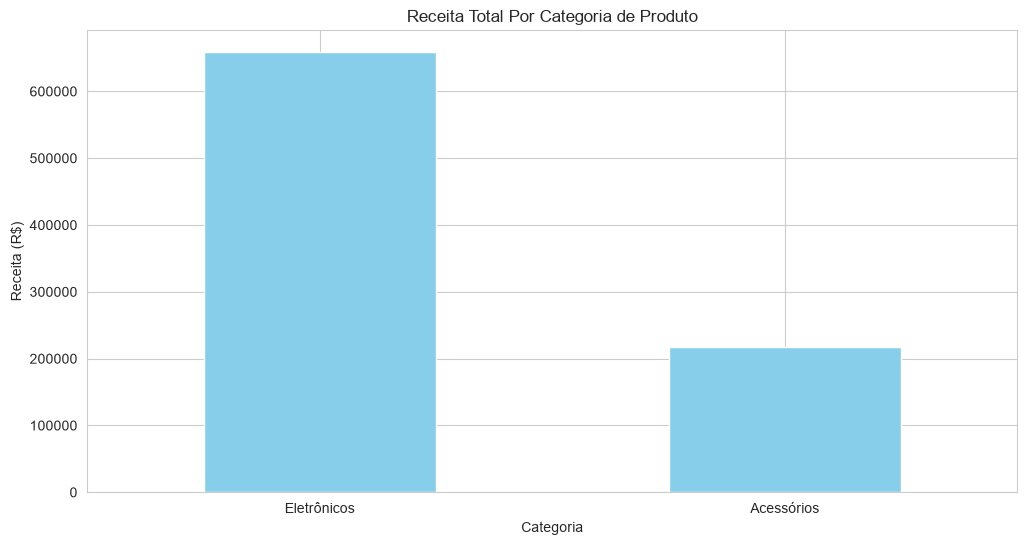

In [31]:
# Gráfico 1: Receita por Categoria
receita_por_categoria.plot(kind = 'bar', color = 'skyblue')
plt.title('Receita Total Por Categoria de Produto')
plt.ylabel('Receita (R$)')
plt.xlabel('Categoria')
plt.xticks(rotation = 0)
plt.show()

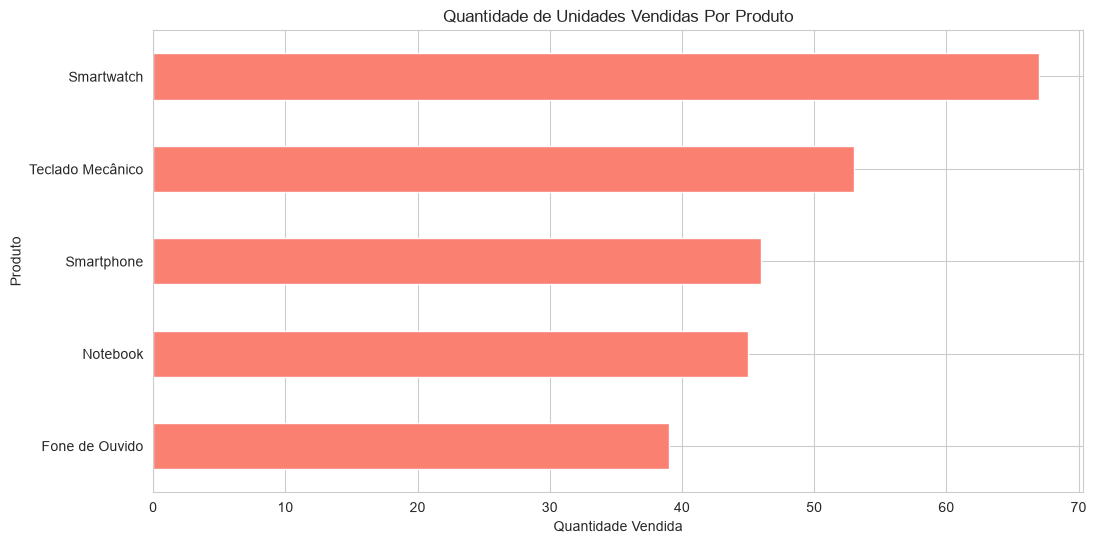

In [32]:
# Gráfico 2: Quantidade Vendida por Produto
produto_mais_vendido.plot(kind = 'barh', color = 'salmon')
plt.title('Quantidade de Unidades Vendidas Por Produto')
plt.ylabel('Produto')
plt.xlabel('Quantidade Vendida')
plt.gca().invert_yaxis() # Inverte o eixo para o maior valor ficar no topo
plt.show()

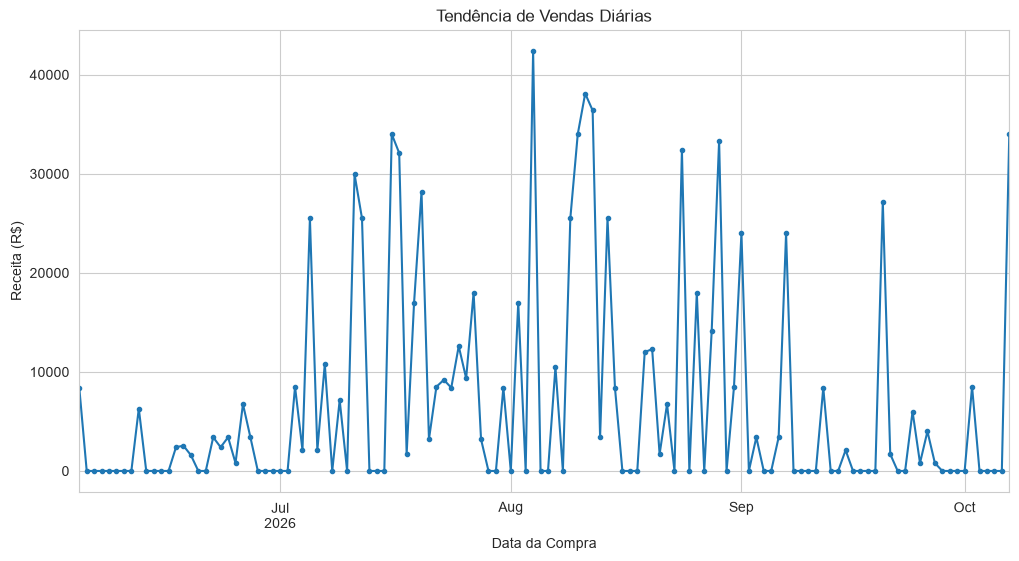

In [33]:
# Gráfico 3: Tendência de Vendas ao Longo do Tempo
vendas_por_dia.plot(kind = 'line', marker = '.', linestyle = '-')
plt.title('Tendência de Vendas Diárias')
plt.ylabel('Receita (R$)')
plt.xlabel('Data da Compra')
plt.grid(True)
plt.show()

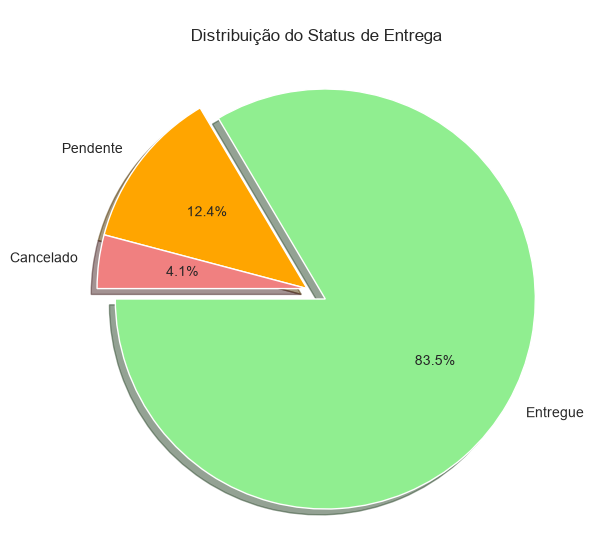

In [34]:
# Gráfico 4: Distribuição do Status de Entrega no formato 3D

# Conta quantas vezes aparece cada status de entrega
status_counts = df_limpo['Status_Entrega'].value_counts()

# Descobre a posição (índice) da fatia com maior valor para destacá-la
maior_idx = status_counts.argmax()

# Cria a lista explode: desloca 0.1 para a maior fatia e 0 para as outras
explode = [0.1 if i == maior_idx else 0 for i in range(len(status_counts))]

plt.figure(figsize = (6,6))

plt.pie(
    status_counts,                 
    labels = status_counts.index,  
    autopct = '%1.1f%%',           
    startangle = 180,              
    colors = ['lightgreen',        
              'orange',            
              'lightcoral'],       
    explode = explode,             
    shadow = True                  
)

plt.title('\nDistribuição do Status de Entrega\n')  
plt.axis('equal')                                   
plt.show()                                                               

## 7. Conclusão

O fluxo aplicado — diagnóstico de anomalias, tratamento de valores ausentes, remoção de duplicatas, correção de tipos e filtragem de outliers — transformou uma base sintética intencionalmente corrompida em um dataset internamente consistente, pronto para suportar análises confiáveis.

Alguns pontos que reforcei com este projeto:

1. **Ordem importa no tratamento de dados.** Tratar valores ausentes antes de remover outliers (e não o contrário) evita perder informação que ainda pode ser recuperada por imputação.
2. **A escolha da estratégia de imputação depende da distribuição.** Usei mediana para `Quantidade` por ser mais robusta a outliers do que a média, e moda para a variável categórica `Status_Entrega`.
3. **Nem todo dado ausente deve ser imputado.** Em `Cliente_ID` e `Preco_Unitario`, optei por remover as linhas em vez de inferir um valor, já que não havia base confiável para estimar essas informações.

Dados limpos não geram, por si só, uma conclusão de negócio — mas são pré-requisito para que qualquer análise posterior seja minimamente confiável.